# Saliency Maps

In [18]:
import xarray as xr

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients, run_forecast_with_integrated_gradients
from pkg.plots.saliency_plots import plot_surface_saliency, plot_atmospheric_saliency
from pkg.plots.plot_variable import plot_variable

In [28]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input = xr.open_dataset(input_path).load()
climatology = xr.open_dataset(climatology_path)

## Run Forecast

### Vanilla and Grad_x_Input Gradient

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=False
)

### Integrated Gradients

In [ ]:
run_forecast_with_integrated_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    m_steps=1,
    upload_to_gcs=False
)

## Plot Results

In [5]:
saliency_path = "../data/saliency_maps/zeynep_wind_grad_saliency.nc"
saliency_path_grad_x_input = "../data/saliency_maps/zeynep_wind_grad_grad_x_input.nc"
saliency_path_integrated_gradients = "../data/saliency_maps/zeynep_wind_grad_integrated.nc"

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
sal_ds_integrated_gradients = xr.open_dataset(saliency_path_integrated_gradients)

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


### Surface Saliency

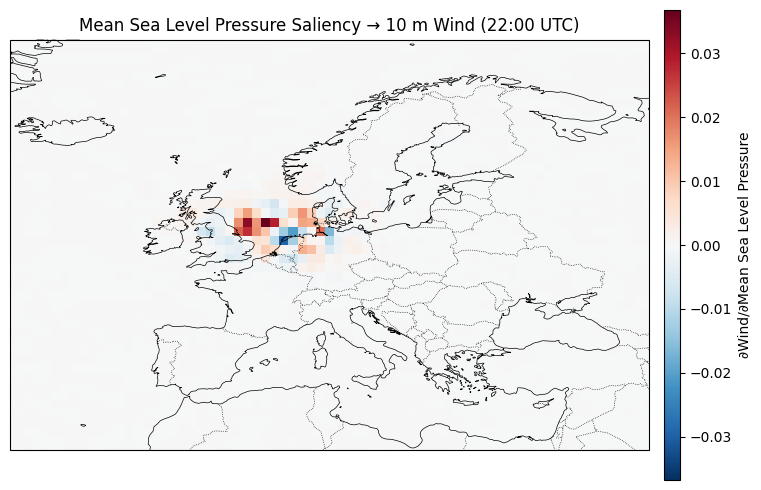

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

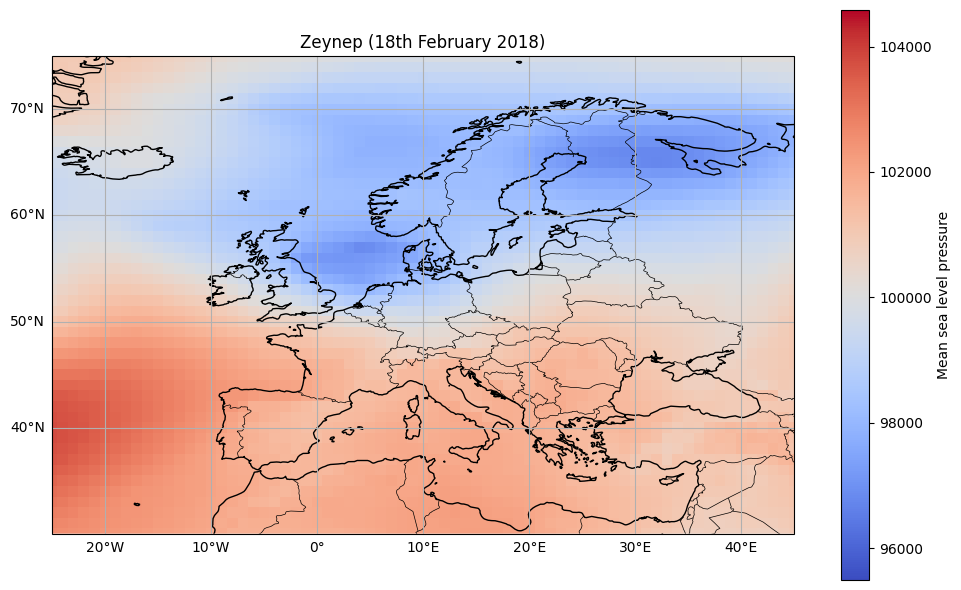

In [49]:
# saliency data: sal_ds (vanilla gradients), sal_ds_grad_x_input, sal_ds_integrated_gradients
saliency_data = sal_ds_integrated_gradients

# surface variables: "2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind", 
# "total_precipitation_6hr", "mean_sea_level_pressure"
surf_var = "mean_sea_level_pressure"

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1  # Second to last time step 

plot_surface_saliency(saliency_data, input, surf_var, time_index=time)

plot_variable(
    input,
    time=time,
    level=None,
    var_name=surf_var,
    title="Zeynep (18th February 2018)",
)

### Atmospheric Saliency

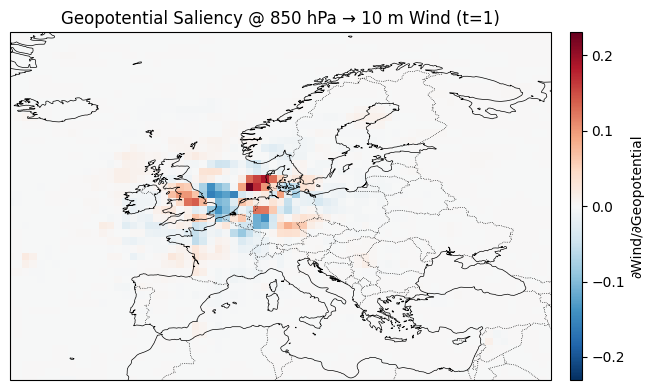

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

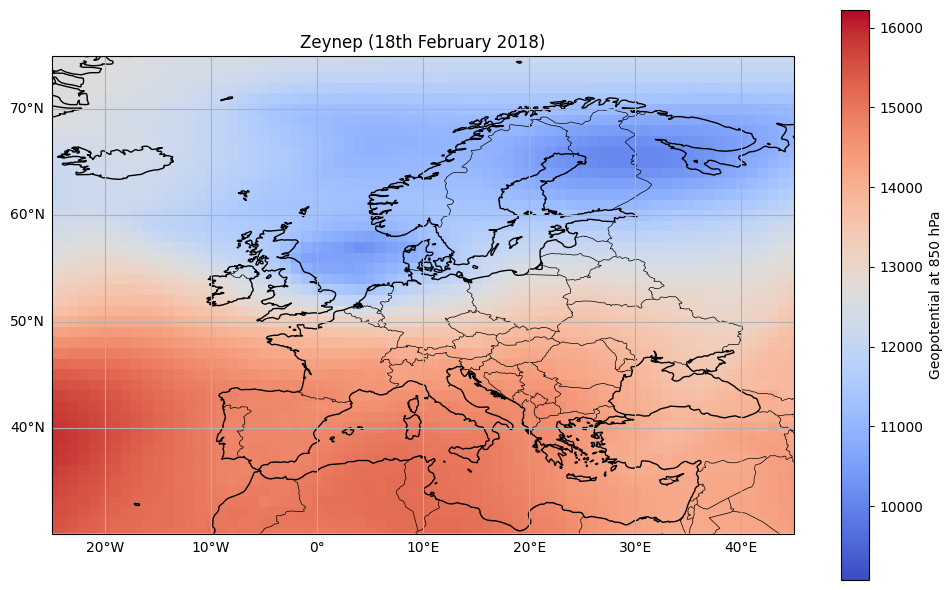

In [52]:
# saliency data: sal_ds (vanilla gradients), sal_ds_grad_x_input, sal_ds_integrated_gradients
saliency_data = sal_ds_integrated_gradients

# atmospheric variables: geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity
varname = "geopotential"

# level
level = 850

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1

# extent: [lon_min, lon_max, lat_min, lat_max]
extent=[-25, 45, 30, 75]


plot_atmospheric_saliency(
    sal_ds=saliency_data,
    input_ds=input,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent
)

plot_variable(
    input,
    time=time,
    level=level,
    var_name=varname,
    extent=extent,
    title="Zeynep (18th February 2018)",
)